## Mapping Surface Runoff Susceptibility in Nisqually River Watershed

#### Data Setup (Required Downloads)

Before running the notebook, download the following datasets and place them in the appropriate folders.  
The notebook will create the project directory structure automatically, but you will need to place downloaded data into the corresponding folders on your local machine. 

SRTM DEM and MACA climate data are accessed and downloaded programmatically within the notebook and do not require manual download.

Note: File paths in the notebook may need to be updated to match your local directory structure. The workflow could also be adapted to another HUC8 watershed if desired.

##### 1. Watershed Boundary (USGS WBD)
- Source: https://www.usgs.gov/national-hydrography/watershed-boundary-dataset  
- Map Downloader Link: https://apps.nationalmap.gov/downloader/#/
- Download the HUC8 watershed boundary that includes the Nisqually River watershed (HUC8: 17110015)  
- Place files in: watershed-boundary-dataset/


##### 2. NLCD Impervious Surface
- Source: https://www.mrlc.gov/viewer/
- Product: NLCD Impervious Surface (30 m) for Study Area
- Place files in: nlcd-impervious/

##### 3. Soils (NRCS gSSURGO)
- Source: https://www.nrcs.usda.gov/resources/data-and-reports/gridded-soil-survey-geographic-gssurgo-database
- Download gSSURGO for Washington State (geodatabase)
- Place files in: soils/

In [132]:
# Import packages for working with files and folders
import os
import pathlib

# Import package for working with geospatial data
import geopandas as gpd

# Import package for working with tabular data
import pandas as pd

# Import libaray for plotting
import matplotlib.pyplot as plt

# Import library for working with scientific computation
import numpy as np

# Import library for making interactive plots with vector/tabular data
import hvplot.pandas 

# Import library for making interactive plot
import holoviews as hv

# Import for working with zip files
import zipfile

# Import for creating file folders
from pathlib import Path

# Access NASA earth data (topography)
import earthaccess

# File pattern for data
from glob import glob

# Import libraries for working with raster data
import rioxarray as rxr
import xarray as xr
import xrspatial

# Import library plotting raster data
import matplotlib.pyplot as plt

# Import library for merging raster data
from rioxarray.merge import merge_arrays

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import rioxarray as rxr

# Read elevation raster
from pysheds.grid import Grid

# Import for bilinear resampling during reprojection
from rasterio.enums import Resampling

# Import library for working with fuzzy logic
import skfuzzy as fuzz

In [2]:
# Create base project directory
project_dir = os.path.join(
    pathlib.Path.home(),
    "Documents",
    "education",
    "earth-data-analytics",
    "spring-2026-data",
    "surface-runoff-susceptibility-model"
)

# Define all directories in one dictionary
dirs = {
    "project": project_dir,
    "wbd": os.path.join(project_dir, "watershed-boundary-dataset"),
    "topography": os.path.join(project_dir, "topography"),
    "soils": os.path.join(project_dir, "soils"),
    "climate": os.path.join(project_dir, "climate"),
    "impervious": os.path.join(project_dir, "nlcd-impervious"),
    "inputs": os.path.join(project_dir, "final_inputs_5070"), 
}

# Create all directories
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Assign individual dir variables
wbd_dir = dirs["wbd"]
topography_dir = dirs["topography"]
soils_dir = dirs["soils"]
climate_dir = dirs["climate"]
impervious_dir = dirs["impervious"]

# Check one of them
print(wbd_dir)
print(os.path.exists(wbd_dir))

C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\watershed-boundary-dataset
True


In [3]:
# Intialize path to DEM raster for pysheds use later
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Conditionally read the DEM raster if it exists, otherwise raise an error
if not os.path.exists(dem_5070_path):
    raise FileNotFoundError(f"DEM not found: {dem_5070_path}")

# Read the DEM raster using pysheds to create a grid object for hydrological analysis
grid = Grid.from_raster(dem_5070_path)
print("Grid ready")

Grid ready


#### Study Area - Nisqually River Watershed, WA

In [4]:
# Path to the downloaded zip file
zip_path = os.path.join(wbd_dir, "WBD_17_HU2_GPKG.zip")

# Extracted directory path
extract_dir = os.path.join(wbd_dir, "extracted")
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to GeoPackage (after unzip)
wbd_gpkg_path = os.path.join(extract_dir, "WBD_17_HU2_GPKG.gpkg")

# Read HUC8 layer
wbd_gdf = gpd.read_file(wbd_gpkg_path, layer="WBDHU8")

# Check the first few rows
print(wbd_gdf.head())

                                    tnmid  \
0  {3DB62677-1E95-4C7F-A328-2DF39761B05D}   
1  {C19C3336-0531-43B8-8DAC-569C87D4E46C}   
2  {1F9A8978-7AF6-4B64-83A8-6296AF7194FD}   
3  {31964435-132E-4924-ADF4-5D732EBE86D9}   
4  {E601469F-456B-46E2-9AD8-49049D17B6C5}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
1  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
2  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
3  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
4  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   
1  Natural Resources and Conservation Service and...            None   
2  Natural Resources and Conservation 

In [5]:
# Check the columns
print(wbd_gdf.columns)

Index(['tnmid', 'metasourceid', 'sourcedatadesc', 'sourceoriginator',
       'sourcefeatureid', 'loaddate', 'referencegnis_ids', 'areaacres',
       'areasqkm', 'states', 'huc8', 'name', 'shape_Length', 'shape_Area',
       'geometry'],
      dtype='object')


In [6]:
# Check the geometry type
wbd_gdf.head()

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
0,{3DB62677-1E95-4C7F-A328-2DF39761B05D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,455018.41,1841.40,OR,17090007,Middle Willamette,NaN,NaN,"POLYGON ((-123.04359 45.38033, -123.04345 45.3..."
1,{C19C3336-0531-43B8-8DAC-569C87D4E46C},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1136527,857035.12,3468.30,OR,17090004,Mckenzie,NaN,NaN,"POLYGON ((-122.02273 44.50785, -122.02237 44.5..."
2,{1F9A8978-7AF6-4B64-83A8-6296AF7194FD},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,1198333.82,4849.49,OR,17090003,Upper Willamette,NaN,NaN,"POLYGON ((-123.38229 44.90266, -123.38196 44.9..."
3,{31964435-132E-4924-ADF4-5D732EBE86D9},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1150077,666390.78,2696.79,OR,17090006,South Santiam,NaN,NaN,"POLYGON ((-122.66308 44.76978, -122.66266 44.7..."
4,{E601469F-456B-46E2-9AD8-49049D17B6C5},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,391131,571545.15,2312.96,WA,17010307,Lower Spokane,NaN,NaN,"POLYGON ((-117.9992 48.12883, -117.99877 48.12..."


In [7]:
# Check for the Nisqually watershed
wbd_gdf[wbd_gdf["name"].str.contains("Nisqually", case=False)]

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
227,{AB20B6D1-23E0-4AEB-A1EC-55722FB6D0DE},{A9DB8B60-5A4A-4FFC-8BE7-FA64FC77FE78},Pierce 2020,"Pierce County Washington, Washington State Dep...",None,2024-10-30 13:39:19,1511938,492844.38,1994.47,WA,17110015,Nisqually,NaN,NaN,"MULTIPOLYGON (((-122.68186 47.09905, -122.6813..."


In [8]:
# Subset to just the Nisqually watershed
nisqually_gdf = wbd_gdf[wbd_gdf["huc8"] == "17110015"]

In [9]:
# Check the name of the watershed
print(nisqually_gdf["name"])

227    Nisqually
Name: name, dtype: object


<Axes: >

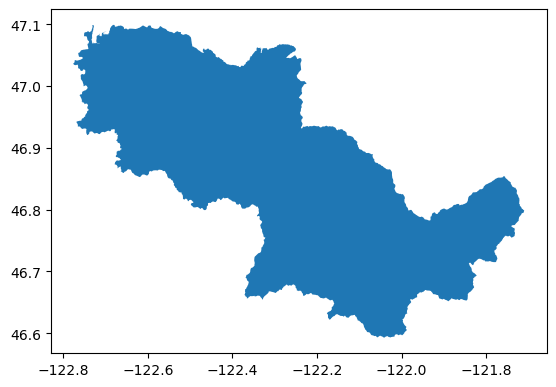

In [10]:
# Plot to see that it worked
nisqually_gdf.plot()

In [11]:
# Plot the results with web tile images
nisqually_gdf_plot = nisqually_gdf.hvplot(
    geo=True, tiles='EsriImagery',
    fill_color=None, line_color='white',
    title='Nisqually Watershed (HUC8)',
    frame_width=500,
    xlabel="Longitude",
    ylabel="Latitude")

# Display the plot with esri imagery
nisqually_gdf_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### SRTM NASA DEM data downlaod (30-m resolution)


In [12]:
# Set up Earth Access
earthaccess.login()

In [13]:
# Search for SRTM data
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
AST14DEM ASTER Digital Elevation Model V004
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_SC NASA

In [14]:
# File pattern for data
nisqually_gdf_srtm_pattern = os.path.join(topography_dir, '*.hgt.zip')

# Study area for topo data
nisqually_gdf_elev_bounds = tuple(nisqually_gdf.total_bounds)

# Add buffer
buffer = 0.025
nisqually_xmin, nisqually_ymin, nisqually_xmax, nisqually_ymax = nisqually_gdf_elev_bounds
nisqually_elev_bounds_buffer = (nisqually_xmin - buffer,
                                 nisqually_ymin - buffer,
                                 nisqually_xmax + buffer,
                                 nisqually_ymax + buffer)

# Look at the results
srtm_files = glob(nisqually_gdf_srtm_pattern)

if not srtm_files:

    # Search for data
    nisqually_gdf_srtm_search = earthaccess.search_data(
        short_name = 'SRTMGL3',
        bounding_box = nisqually_elev_bounds_buffer
    )

    # Download data
    nisqually_gdf_srtm_results = earthaccess.download(
        nisqually_gdf_srtm_search,
        topography_dir
    )

# Add text if files already downloaded
else:
    print("SRTM files already downloaded")
    nisqually_gdf_srtm_results = srtm_files

SRTM files already downloaded


In [15]:
# Check it out
nisqually_gdf_srtm_results

['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W123.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W123.SRTMGL3.hgt.zip']

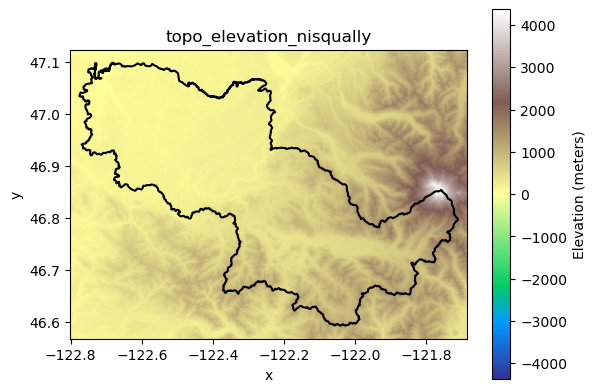

In [16]:
nisqually_gdf_srtm_da_list = []
for srtm_path in glob(nisqually_gdf_srtm_pattern):
    tile_da = rxr.open_rasterio(srtm_path, mask_and_scale = True).squeeze()
    srtm_cropped_da = tile_da.rio.clip_box(*nisqually_elev_bounds_buffer)
    nisqually_gdf_srtm_da_list.append(srtm_cropped_da)

# Merge 
nisqually_srtm_da = merge_arrays(nisqually_gdf_srtm_da_list)

nisqually_srtm_da.plot(cmap='terrain', cbar_kwargs={'label': 'Elevation (meters)'})

nisqually_gdf.boundary.plot(ax = plt.gca(), color='black')

# Add title
plt.title("topo_elevation_nisqually")

# Check it out
plt.show()

In [17]:
# Save the merged raster to a new file
# Create a copy of the data array to modify for saving
nisqually_save_da = nisqually_srtm_da.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
nisqually_save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
nisqually_save_da.encoding.pop("_FillValue", None)
nisqually_save_da = nisqually_save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_path = os.path.join(topography_dir, "nisqually_dem.tif")

# Save the raster to a new file
nisqually_save_da.rio.to_raster(dem_path)

# Check that the file was saved correctly
print(dem_path)
print(os.path.exists(dem_path))


C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_dem.tif
True


In [18]:
# Check the min and max values
print(nisqually_srtm_da.min().values)
print(nisqually_srtm_da.max().values)

-4.0
4371.0


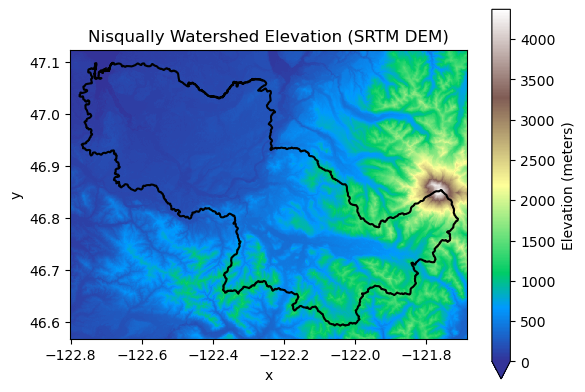

In [19]:
# Plot with limits for better visualization
nisqually_srtm_da.plot(
    cmap="terrain",
    vmin=0,
    vmax=float(nisqually_srtm_da.max()),
    cbar_kwargs={"label": "Elevation (meters)"}
)

# Add watershed boundary
nisqually_gdf.boundary.plot(ax=plt.gca(), color="black")
plt.title("Nisqually Watershed Elevation (SRTM DEM)")
plt.show()

### NLCD Impervious Surface

In [20]:
# Path to zip file
zip_path = os.path.join(impervious_dir, "NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip")

# Unzip to the same directory
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(impervious_dir)

# Check the extracted files
print("Unzipped successfully")

Unzipped successfully


In [21]:
# List the files in the impervious directory to see the extracted contents
for file in os.listdir(impervious_dir):
    print(file)

Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff.aux.xml
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.xml
extracted
nisqually_impervious_5070.tif
NLCD Fractional Impervious Surface.gif
NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip


In [22]:
# Find the tif
tif_files = [
    f for f in os.listdir(impervious_dir)
    if f.lower().endswith((".tif", ".tiff"))
]

# Check the tif files found
impervious_path = os.path.join(impervious_dir, tif_files[0])

# Open it
impervious_da = rxr.open_rasterio(impervious_path, masked=True).squeeze()

# Check the dataarray
print(impervious_da)

<xarray.DataArray (y: 5801, x: 7270)> Size: 169MB
[42173270 values with dtype=float32]
Coordinates:
  * y            (y) float64 46kB 3.01e+06 3.01e+06 ... 2.836e+06 2.836e+06
  * x            (x) float64 58kB -2.087e+06 -2.087e+06 ... -1.869e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        100
    STATISTICS_MEAN:           3.2224650619265
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         12.153386299596
    STATISTICS_VALID_PERCENT:  63.85
    scale_factor:              1.0
    add_offset:                0.0


In [23]:
# Check CRS, bounds, and resolution
print(impervious_da.rio.crs)
print(impervious_da.rio.bounds())
print(impervious_da.rio.resolution())

PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
(-2087175.0, 2835735.0, -1869075.0, 3009765.0)
(30.0, -30.0)


In [24]:
impervious_5070 = impervious_da.rio.reproject("EPSG:5070")

In [25]:
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

impervious_clip = impervious_5070.rio.clip(
    nisqually_gdf_5070.geometry,
    nisqually_gdf_5070.crs,
    drop=True
)

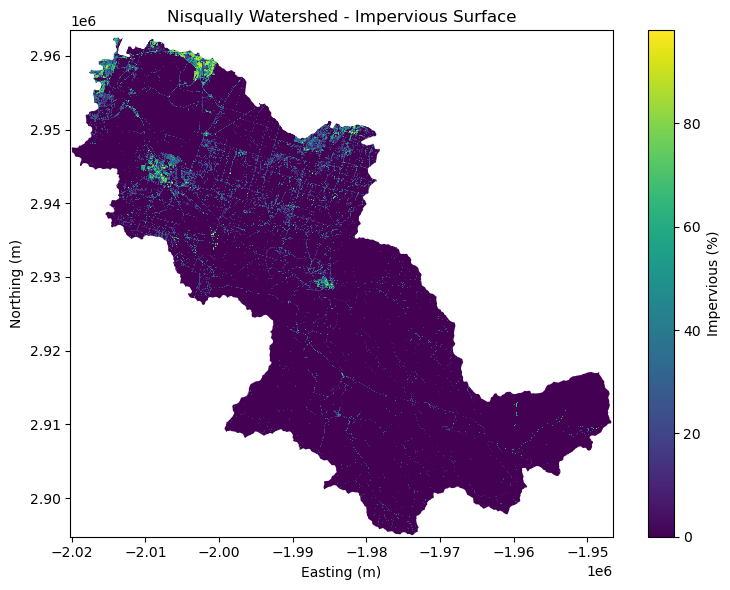

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

impervious_clip.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Impervious (%)"}
)

nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="white",
    linewidth=1.5
)

ax.set_title("Nisqually Watershed - Impervious Surface")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

In [27]:
def clean_and_save(da, path):
    """Function to clean the data array and save it to a raster file.
    
    Args:
    da (xarray.DataArray): The data array to clean and save
    path (str): The file path to save the raster to
    
    Returns:
    None
    """
    save_da = da.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32")
    save_da = save_da.fillna(-9999)
    save_da = save_da.rio.write_nodata(-9999)
    save_da.rio.to_raster(path, dtype="float32")
    print(f"Saved: {path}")

In [28]:
impervious_5070_path = os.path.join(
    impervious_dir,
    "nisqually_impervious_5070.tif"
)

clean_and_save(impervious_clip, impervious_5070_path)

Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\nlcd-impervious\nisqually_impervious_5070.tif


### MACA Climate Data

In [29]:
# Create function to convert longitude values
def convert_longitude(longitude):

    """
    Function to convert longitude

    Args:
    longitude:

    Returns:Function to convert longitude
    """
    
    return (longitude - 360) if longitude > 180 else longitude 

In [30]:
# Create directory for file
climate_pattern = os.path.join(climate_dir, '*.nc')
climate_pattern

'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\*.nc'

In [31]:
# Define some parameters
site_name = "Nisqually"
site_gdf = nisqually_gdf
date_range = "2041_2045"
model = "CCSM4"
rcp_value = "rcp45"
climate_var = "pr"

In [32]:
# Create a maca path
climate_path = os.path.join(
    climate_dir,
    f"maca_{model}_{site_name}_{date_range}_CONUS_daily.nc"
)

In [33]:
# Construct the URL where the climate data lives
climate_url = (
    "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
    "/MACAV2"
    f"/{model}"
    "/macav2metdata"
    f"_{climate_var}"
    f"_{model}_r6i1p1"
    f"_{rcp_value}"
    f"_{date_range}_CONUS"
    "_daily.nc"
)

In [34]:
# Check out the url
climate_url

'http://thredds.northwestknowledge.net:8080/thredds/dodsC/MACAV2/CCSM4/macav2metdata_pr_CCSM4_r6i1p1_rcp45_2041_2045_CONUS_daily.nc'

In [35]:
# Open the dataset using xarray
ds = xr.open_dataset(climate_url)
print(ds.data_vars)

Data variables:
    precipitation  (time, lat, lon) float32 6GB ...


In [36]:
# Check if the variable is "pr" or "precipitation" and assign to climate_da
climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]
print(climate_da)

<xarray.DataArray 'precipitation' (time: 1826, lat: 585, lon: 1386)> Size: 6GB
[1480539060 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2041-01-01 2041-01-02 ... 2045-12-31
  * lat      (lat) float64 5kB 25.06 25.1 25.15 25.19 ... 49.27 49.31 49.35 49.4
  * lon      (lon) float64 11kB 235.2 235.3 235.3 235.4 ... 292.9 292.9 292.9
Attributes:
    long_name:      Precipitation
    units:          mm
    grid_mapping:   crs
    standard_name:  precipitation
    cell_methods:   time: sum(interval: 24 hours)
    comments:       Total daily precipitation at surface; includes both liqui...
    _ChunkSizes:    [162  51 123]


In [37]:
# Check remote point values to make sure it looks right
pt_raw = climate_da.sel(lat=46.85, lon=237.8, method="nearest")
print("Remote raw point min/max:", float(pt_raw.min()), float(pt_raw.max()))

Remote raw point min/max: 0.0 92.08182525634766


In [38]:
# Convert longitude values to the range [-180, 180]
climate_da = climate_da.assign_coords(
    lon=(((climate_da.lon + 180) % 360) - 180).data
).sortby("lon")

In [39]:
# Check the converted point values to make sure it looks right
pt_conv = climate_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote converted point min/max:", float(pt_conv.min()), float(pt_conv.max()))

Remote converted point min/max: 0.0 92.08182525634766


In [40]:
# Match the CRS of the climate data to the watershed boundary
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")

# Create a bounding box for the watershed
minx, miny, maxx, maxy = nisqually_4326.total_bounds
print(minx, miny, maxx, maxy)

-122.77620911906662 46.59305184666876 -121.71018763313434 47.09906060599487


In [41]:
# Crop the climate data to the bounding box of the watershed
climate_da_cropped = climate_da.sel(
    lon=slice(minx, maxx),
    lat=slice(miny, maxy)
)

In [42]:
# Check the cropped point values to make sure it looks right
pt_crop = climate_da_cropped.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote cropped point min/max:", float(pt_crop.min()), float(pt_crop.max()))

# Check the cropped slice values to make sure it looks right
test_crop = climate_da_cropped.isel(time=0)
print("Remote cropped slice min/max:", float(test_crop.min()), float(test_crop.max()))
print(climate_da_cropped.shape)

Remote cropped point min/max: 0.0 92.08182525634766
Remote cropped slice min/max: 2.5459516048431396 17.12653923034668
(1826, 12, 26)


In [43]:
# Load the cropped subset into memory
climate_da_cropped = climate_da_cropped.load()
print("Cropped subset loaded into memory")

Cropped subset loaded into memory


In [44]:
# Create path for cropped file
cropped_path = os.path.join(
    climate_dir,
    "maca_CCSM4_Nisqually_2041_2045_cropped.nc"
)

if not os.path.exists(cropped_path):
    climate_da_cropped.to_netcdf(cropped_path)
    print("Saved cropped file:", cropped_path)
else:
    print("File already exists, not overwriting:", cropped_path)

File already exists, not overwriting: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_Nisqually_2041_2045_cropped.nc


In [45]:
# Check the cropped file by opening it again
ds_check = xr.open_dataset(cropped_path)
print(ds_check.data_vars)

# Check if the variable is "pr" or "precipitation" and assign to check_da
check_da = ds_check["precipitation"] if "precipitation" in ds_check.data_vars else ds_check["pr"]

# Check the cropped point values to make sure it looks right
pt_check = check_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Local cropped point min/max:", float(pt_check.min()), float(pt_check.max()))

# Check the cropped slice values to make sure it looks right
test_check = check_da.isel(time=0)
print("Local cropped slice min/max:", float(test_check.min()), float(test_check.max()))

Data variables:
    precipitation  (time, lat, lon) float32 2MB ...
Local cropped point min/max: 0.0 92.08182525634766
Local cropped slice min/max: 2.5459516048431396 17.12653923034668


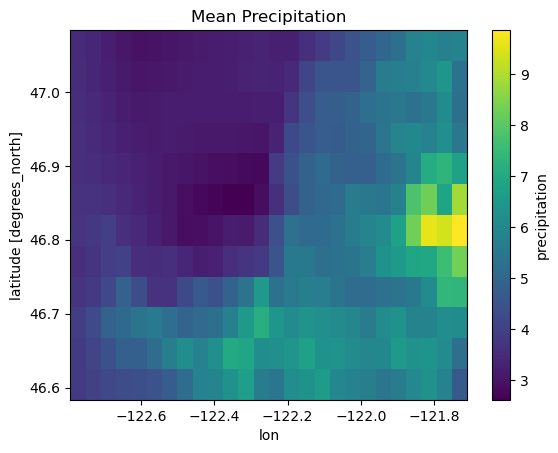

In [46]:
# Plot the mean precipitation to check it out
climate_mean = check_da.mean(dim="time")
climate_mean.plot()

# Add title
plt.title("Mean Precipitation")
plt.show()

In [47]:
# Check the min and max values of the mean precipitation
print(float(climate_mean.min()), float(climate_mean.max()))

2.611323833465576 9.863235473632812


In [48]:
# Check the shape of the cropped data array
climate_da_cropped.shape

(1826, 12, 26)

#### Function for downloading all maca data cropped precip

In [49]:
# Create function to get all climate data
# *Created with help of ChatGPT, refined by author*
def get_maca_cropped_precip(
    model,
    scenario,
    date_range,
    watershed_gdf,
    climate_dir,
    site_name="Nisqually",
):
    """
    Function to open a remote MACA daily precipitation dataset for one time chunk,
    convert longitude from 0-360 to -180-180, crop to the watershed
    bounding box, load the cropped daily subset into memory, and save
    it locally as a NetCDF file.

    Args:
    model (str): MACA climate model name, e.g. "CCSM4".
    scenario (str): Scenario name, e.g. "historical", "rcp45", or "rcp85".
    date_range (str): Time chunk string, e.g. "1975_1979" or "2041_2045".
    watershed_gdf (geopandas.GeoDataFrame): Watershed boundary used for cropping.
    climate_dir (str): Directory where the cropped NetCDF file will be saved.
    site_name (str): Name of the study site for use in the output filename. Defaults to "Nisqually".

    Returns
    str: Path to the saved cropped NetCDF file.
    """

    # MACA ensemble convention
    ensemble = "r6i1p1" if model == "CCSM4" else "r1i1p1"

    # Build filename differently for historical vs future scenarios
    if scenario == "historical":
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_historical_{date_range}_CONUS_daily.nc"
        )
    else:
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_{scenario}_{date_range}_CONUS_daily.nc"
        )

    # Build remote URL
    climate_url = (
        "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
        f"/MACAV2/{model}/{remote_filename}"
    )

    # Build local output path
    out_path = os.path.join(
        climate_dir,
        f"maca_{model}_{scenario}_{site_name}_{date_range}_cropped.nc"
    )

    # Skip if already exists
    if os.path.exists(out_path):
        print(f"Already exists: {out_path}")
        return out_path

    # Print message about opening remote dataset
    print(f"Opening remote dataset for {scenario} {date_range}...")

    # Open remote dataset
    ds = xr.open_dataset(climate_url)

    # Grab precipitation variable
    climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]

    # Convert longitude from 0-360 to -180-180 and sort
    climate_da = climate_da.assign_coords(
        lon=(((climate_da.lon + 180) % 360) - 180).data
    ).sortby("lon")

    # Watershed bounds in EPSG:4326 to match MACA coordinates
    watershed_4326 = watershed_gdf.to_crs("EPSG:4326")
    bounds = watershed_4326.total_bounds

    # Add buffer
    buffer = 0.05
    xmin, ymin, xmax, ymax = bounds
    bounds_buffer = (xmin - buffer, ymin - buffer, xmax + buffer, ymax + buffer)

    # Crop to buffered bounding box
    climate_da_cropped = climate_da.sel(
        lon=slice(bounds_buffer[0], bounds_buffer[2]),
        lat=slice(bounds_buffer[1], bounds_buffer[3])
    )

    # Load cropped subset into memory before saving
    climate_da_cropped = climate_da_cropped.load()

    # Quick sanity check on first day
    test = climate_da_cropped.isel(time=0)
    print("First-day cropped min/max:", float(test.min()), float(test.max()))

    # Save cropped daily data
    climate_da_cropped.to_netcdf(out_path)

    # Close remote dataset
    ds.close()

    print(f"Saved: {out_path}")
    return out_path

In [50]:
# Make sure function works by running it for one time chunk
test_path = get_maca_cropped_precip(
    model="CCSM4",
    scenario="rcp45",
    date_range="2046_2050",
    watershed_gdf=nisqually_gdf,
    climate_dir=climate_dir,
    site_name="Nisqually"
)

# Check the output path
print(test_path)

Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc
C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc


In [51]:
# Define historical date range for looping
historical_ranges = [
    "1975_1979",
    "1980_1984",
    "1985_1989",
    "1990_1994",
    "1995_1999",
    "2000_2004",
    "2005_2005",
]

# Define future date range for looping
future_ranges = [
    "2041_2045",
    "2046_2050",
    "2051_2055",
    "2056_2060",
    "2061_2065",
    "2066_2070",
]

In [52]:
# Create loop for all historical and future time chunks
saved_files = []

# Loop through historical ranges
for tr in historical_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="historical",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Loop through future ranges
for tr in future_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="rcp45",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Check the list of saved files
saved_files

Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1985_1989_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1990_1994_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1995_1999_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytic

['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1985_1989_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1990_1994_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1995_1999_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\sur

### NRCS Soil data download

Path: "C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\soils\gSSURGO_WA.zip"

In [53]:
# Path to the downloaded zip file
soils_zip_path = os.path.join(soils_dir, "gSSURGO_WA.zip")

# Extracted directory path
soils_extract_dir = os.path.join(soils_dir, "extracted")
os.makedirs(soils_extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(soils_zip_path, 'r') as zip_ref:
    zip_ref.extractall(soils_extract_dir)

# Path to GeoPackage (after unzip)
soils_gpkg_path = os.path.join(soils_extract_dir, "gSSURGO_WA.gdb")

In [54]:
# Make sure it exists
soils_gdf = gpd.read_file(soils_gpkg_path)

c:\Users\nymve\miniconda3\envs\earth-analytics-python\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'gSSURGO_WA.gdb': 'chaashto' (default), 'chconsistence', 'chdesgnsuffix', 'chfrags', 'chorizon', 'chpores', 'chstruct', 'chstructgrp', 'chtext', 'chtexture', 'chtexturegrp', 'chtexturemod', 'chunified', 'cocanopycover', 'cocropyld', 'codiagfeatures', 'coecoclass', 'coeplants', 'coerosionacc', 'coforprod', 'coforprodo', 'cogeomordesc', 'cohydriccriteria', 'comonth', 'component', 'copm', 'copmgrp', 'copwindbreak', 'corestrictions', 'cosoilmoist', 'cosoiltemp', 'cosurffrags', 'cosurfmorphgc', 'cosurfmorphhpp', 'cosurfmorphmr', 'cosurfmorphss', 'cotaxfmmin', 'cotaxmoistcl', 'cotext', 'cotreestomng', 'cotxfmother', 'distinterpmd', 'distlegendmd', 'distmd', 'featdesc', 'laoverlap', 'legend', 'legendtext', 'mapunit', 'month', 'muaggatt', 'muaoverlap', 'mucropyld', 'mutext', 'sacatalog', 'sdvalgorithm', 'sdvattribute', 'sdvfolder', 'sdvfolderattribute', 'm

In [55]:
# Check the map unit attributes layer
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")

# Check the first few rows of the map unit attributes
map_unit_attributes.head()

# Check the columns in the map unit attributes
map_unit_attributes.columns

Index(['musym', 'muname', 'mustatus', 'slopegraddcp', 'slopegradwta',
       'brockdepmin', 'wtdepannmin', 'wtdepaprjunmin', 'flodfreqdcd',
       'flodfreqmax', 'pondfreqprs', 'aws025wta', 'aws050wta', 'aws0100wta',
       'aws0150wta', 'drclassdcd', 'drclasswettest', 'hydgrpdcd', 'iccdcd',
       'iccdcdpct', 'niccdcd', 'niccdcdpct', 'engdwobdcd', 'engdwbdcd',
       'engdwbll', 'engdwbml', 'engstafdcd', 'engstafll', 'engstafml',
       'engsldcd', 'engsldcp', 'englrsdcd', 'engcmssdcd', 'engcmssmp',
       'urbrecptdcd', 'urbrecptwta', 'forpehrtdcp', 'hydclprs', 'awmmfpwwta',
       'mukey'],
      dtype='object')

In [56]:
# Read the map unit aggregate attributes table
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")
map_unit_attributes.columns = map_unit_attributes.columns.str.lower()

# Read the soils polygon layer
soils = gpd.read_file(soils_gpkg_path, layer="MUPOLYGON")
soils.columns = soils.columns.str.lower()

# Keep only the columns needed for this step
map_unit_attributes_subset = map_unit_attributes[["mukey", "hydgrpdcd"]].dropna()

# Join hydrologic group code to soil polygons
soils_gdf = soils.merge(map_unit_attributes_subset, on="mukey", how="left")

# Simplify hydrologic group values like "A/D" to a single group
def simplify_hydgrp(val):
    if pd.isna(val):
        return None
    return val.split("/")[-1]

# Create a cleaned hydrologic group field
soils_gdf["hydgrp"] = soils_gdf["hydgrpdcd"].apply(simplify_hydgrp)

# Quick checks
print(soils_gdf[["mukey", "hydgrpdcd", "hydgrp"]].head())
print(soils_gdf["hydgrp"].value_counts(dropna=False))

c:\Users\nymve\miniconda3\envs\earth-analytics-python\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


     mukey hydgrpdcd hydgrp
0  1451383       C/D      D
1  1483187         A      A
2  1151905       NaN   None
3  1151909         D      D
4  1451951         D      D
hydgrp
B       224938
C       135653
D        90097
A        70831
None     29157
Name: count, dtype: int64


In [57]:
# Check the CRS of the soils geodataframe
# Keep 5070 for analysis, but reproject to 4326 for plotting
soils_gdf.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

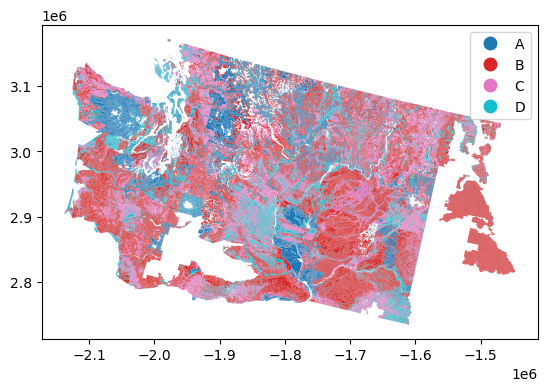

In [58]:
# Check out whole map of hydrologic soil groups
soils_gdf.plot(column="hydgrp", legend=True)

In [59]:
# Check out the columns in the soils geodataframe
print(soils_gdf.columns)

Index(['areasymbol', 'spatialver', 'musym', 'mukey', 'shape_length',
       'shape_area', 'geometry', 'hydgrpdcd', 'hydgrp'],
      dtype='object')


In [60]:
# Make sure in same CRS for clipping and plotting
soil_gdf_5070 = soils_gdf.to_crs("EPSG:5070")
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

In [61]:
# Clip the soil data to the watershed boundary
nisqually_soil_clip = gpd.clip(soil_gdf_5070, nisqually_gdf_5070)

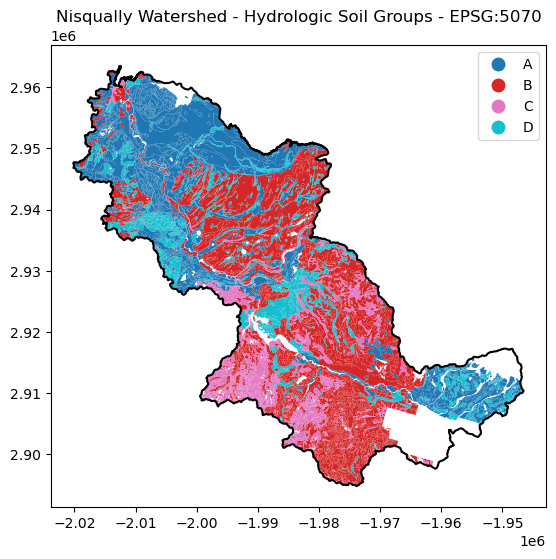

In [62]:
# Plot the clipped soil data
fig, ax = plt.subplots(figsize=(8,6))

# Plot the soil data with the hydrologic group column and a legend
nisqually_soil_clip.plot(
    column="hydgrp",
    ax=ax,
    legend=True
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="black")

# Add title
plt.title("Nisqually Watershed - Hydrologic Soil Groups - EPSG:5070")
plt.show()

In [63]:
# Check the hydrologic group values in the clipped soil data
nisqually_soil_clip["hydgrp"].value_counts(dropna=False)

hydgrp
B       2083
A       1630
D       1537
C        865
None     500
Name: count, dtype: int64

In [64]:
# create a clean modeling version
nisqually_soil_clean = nisqually_soil_clip.dropna(subset=["hydgrp"]).copy()

In [65]:
# Create soil score mapping based on hydrologic group, where A=0.1, B=0.4, C=0.7, D=1.0
soil_score_map = {
    "A": 0.0,
    "B": 0.37,
    "C": 0.78,
    "D": 1.0
}

# Add soil score column to the cleaned soil geodataframe
nisqually_soil_clean["soil_score"] = nisqually_soil_clean["hydgrp"].map(soil_score_map)

# Make sure there are no missing values in the soil score column
nisqually_soil_clean["soil_score"].isna().sum()  

np.int64(0)

In [66]:
# Check the first few rows of the cleaned soil geodataframe
nisqually_soil_polygons = zip(
    nisqually_soil_clean.geometry.values,
    nisqually_soil_clean["soil_score"].values
)

# Rasterize the soil polygons to create a soil score raster
nisqually_soil_raster = grid.rasterize(nisqually_soil_polygons, fill=np.nan)

In [67]:
# Create path for soil raster file
soil_raster_path = os.path.join(soils_dir, "nisqually_soil_score_5070.tif")

# Save the soil score raster to a GeoTIFF file
grid.to_raster(nisqually_soil_raster, soil_raster_path)

# Print the path to the saved soil raster
print("Saved soil raster to:", soil_raster_path)

Saved soil raster to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\soils\nisqually_soil_score_5070.tif


In [68]:
# Open the saved soil raster to check it out
nisqually_soil_da = rxr.open_rasterio(soil_raster_path, masked=True).squeeze()

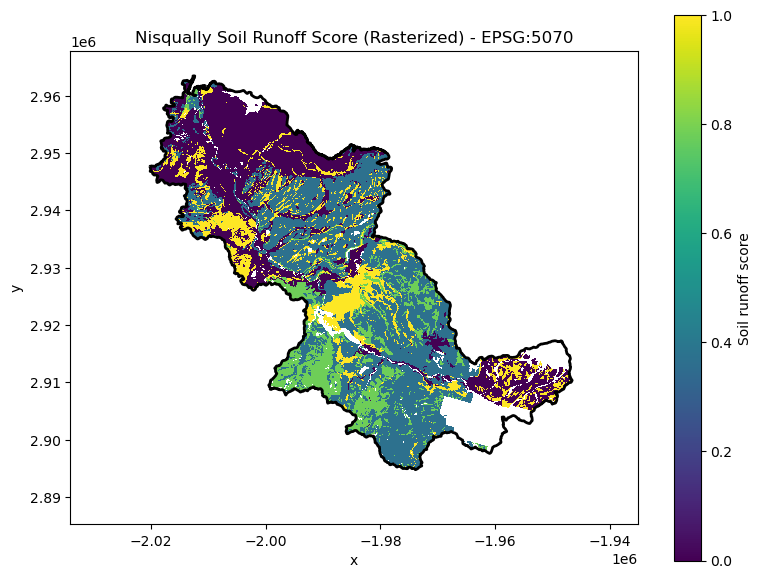

In [69]:
# Plot the soil score raster with the watershed boundary on top
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the soil score raster with a colormap and colorbar
nisqually_soil_da.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Soil runoff score"} # Label for the colorbar
)

# Add watershed boundary on top with white edges
nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2
)

# Add title
ax.set_title("Nisqually Soil Runoff Score (Rasterized) - EPSG:5070")
plt.tight_layout()
plt.show()

## Processing & Analysis

#### SRTM Analysis Slope and Flow Accumulation

In [70]:
# Reproject the SRTM DEM to 5070 to calculate slope 
nisqually_rpj = nisqually_srtm_da.rio.reproject("EPSG:5070")

# Create a copy of the data array to modify for saving
save_da = nisqually_rpj.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)

# Write the nodata value to the raster metadata
save_da = save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Save the raster as float32 with nodata value of -9999
save_da.rio.to_raster(dem_5070_path, dtype="float32")

In [71]:
# Open the reprojected DEM to check it out
dem_5070 = rxr.open_rasterio(dem_5070_path, masked=True).squeeze()

In [72]:
# Calculate slope
nisqually_slope = xrspatial.slope(dem_5070)

In [73]:
slope_5070_path = os.path.join(topography_dir, "nisqually_slope_5070.tif")

save_da = nisqually_slope.copy()
save_da.attrs.pop("_FillValue", None)
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)
save_da = save_da.rio.write_nodata(-9999)

save_da.rio.to_raster(slope_5070_path, dtype="float32")

In [74]:
def reproject_4326(input_path, output_path=None, dst_crs="EPSG:4326"):
    """
    Reproject a raster to a new CRS and save it to a new file for plotting.

    Args:
        input_path (str): Path to the input raster file.
        output_path (str): Path to the output raster file. If None, saves with "_4326" suffix.
        dst_crs (str): Target CRS. Default is "EPSG:4326".

    Returns:
        str: Path to the saved reprojected raster file.
    """

    # Open raster
    da = rxr.open_rasterio(input_path, masked=True).squeeze()

    # Reproject
    da_reprojected = da.rio.reproject(dst_crs)

    # Create output path if not provided
    if output_path is None:
        base, ext = os.path.splitext(input_path)
        base = base.replace("_5070", "")
        output_path = f"{base}_4326{ext}"

    # Clean + standardize before saving
    save_da = da_reprojected.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32")
    save_da = save_da.fillna(-9999)
    save_da = save_da.rio.write_nodata(-9999)

    # Save
    save_da.rio.to_raster(output_path, dtype="float32")

    print(f"Reprojected raster saved to: {output_path}")
    return output_path

In [75]:
# Reproject slope to 4326 for plotting
nisqually_slope_4326_path = reproject_4326(slope_5070_path)

# Open the reprojected slope raster to check it out
nisqually_slope_4326 = rxr.open_rasterio(nisqually_slope_4326_path, masked=True).squeeze()

Reprojected raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_slope_4326.tif


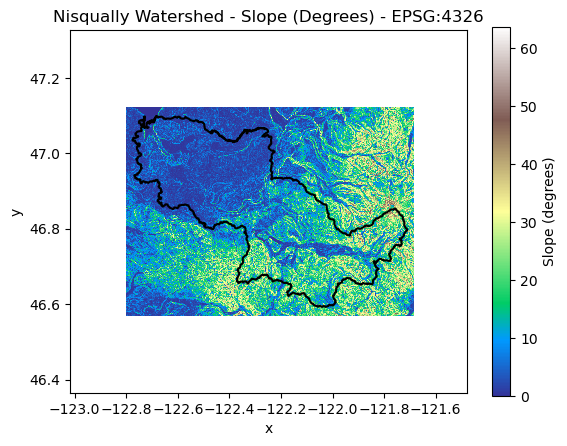

In [76]:
# Plot slope with watershed boundary
fig, ax = plt.subplots()

# Plot slope with a terrain colormap and colorbar with label
nisqually_slope_4326.plot(
    ax=ax,
    cmap='terrain',
    cbar_kwargs={'label': 'Slope (degrees)'}
)

# Add title
ax.set_title("Nisqually Watershed - Slope (Degrees) - EPSG:4326")

# Plot watershed boundary on top
nisqually_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Show the plot
plt.show()

#### Calculate Flow Accumulation

In [77]:
# Read the DEM raster using pysheds
grid = Grid.from_raster(dem_5070_path)
dem = grid.read_raster(dem_5070_path)

In [78]:
# Condition DEM to fill depressions and calculate flow direction
# Fill pits in the DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in the DEM
flood_dem = grid.fill_depressions(pit_filled_dem)

# Resolve flats in the DEM
inflated_dem = grid.resolve_flats(flood_dem)


##### fdir is like a map of arrows, which cell each cell flows into

In [79]:
# Determmine D8 flow direction from DEM
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# Compute flow directions 
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

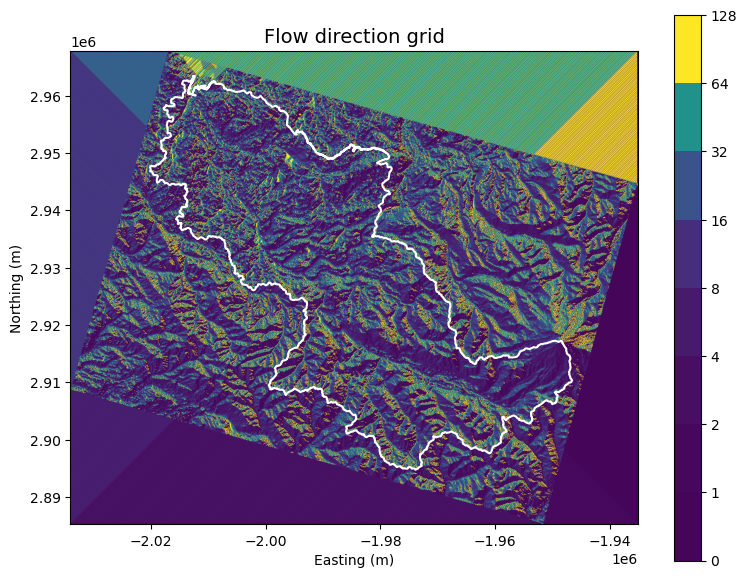

In [80]:
# Replace 0 values with NaN for better visualization
fdir_plot = np.where(fdir == 0, np.nan, fdir)

# Plot flow direction with watershed boundary on top
fig, ax = plt.subplots(figsize=(8,6))

# Plot flow direction with a colormap and colorbar with label
im = ax.imshow(
    fdir_plot,
    extent=grid.extent,
    cmap='viridis',
    zorder=2 # Set zorder to plot below the watershed boundary
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

# Add colorbar with ticks corresponding to flow direction values
boundaries = [0] + sorted(list(dirmap))
plt.colorbar(im, boundaries=boundaries, values=sorted(dirmap))

# Add title and labels
ax.set_title('Flow direction grid', size=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.grid(zorder=-1) # Add gridlines behind the plot

plt.tight_layout()
plt.show()

In [81]:
# Calcuate flow accumulation
acc = grid.accumulation(fdir, dirmap=dirmap)

In [82]:
# Save the flow accumulation raster
flow_acc_path = os.path.join(topography_dir, "nisqually_flow_acc_5070.tif")
grid.to_raster(acc, flow_acc_path)

# Show the path to the saved flow accumulation raster
print("Flow accumulation raster saved to:", flow_acc_path)

Flow accumulation raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_flow_acc_5070.tif


C:\Users\nymve\AppData\Local\Temp\ipykernel_21856\3925235238.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cubehelix").copy()


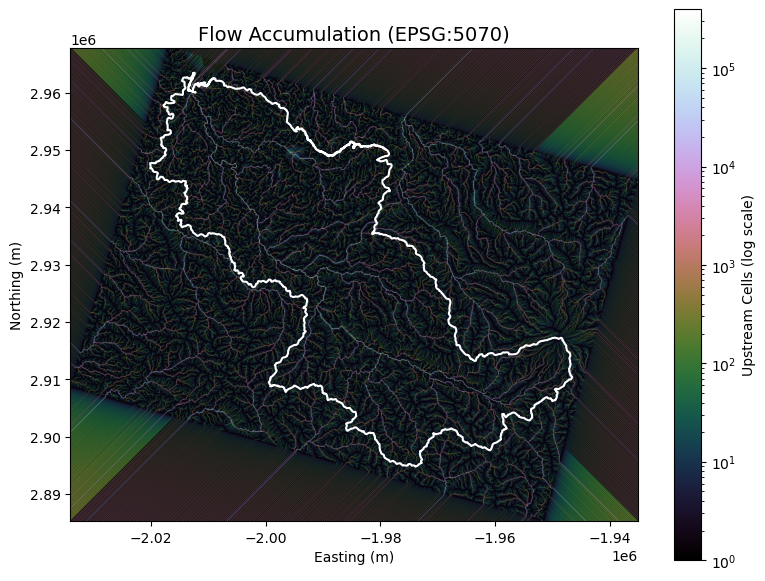

In [83]:
# Open saved 5070 flow accumulation raster
nisqually_flow_acc = rxr.open_rasterio(flow_acc_path, masked=True).squeeze()

# Mask zeros for log scale
acc_plot = np.where(nisqually_flow_acc <= 0, np.nan, nisqually_flow_acc)

# Colormap
cmap = cm.get_cmap("cubehelix").copy()
cmap.set_bad("white")

# Bounds for imshow need order: left, right, bottom, top
left, bottom, right, top = nisqually_flow_acc.rio.bounds()

# Plot flow accumulation with log scale
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
ax.grid(zorder=0)

im = ax.imshow(
    acc_plot,
    extent=(left, right, bottom, top),
    cmap=cmap,
    norm=colors.LogNorm(vmin=1, vmax=np.nanmax(acc_plot)),
    interpolation="bilinear",
    zorder=2
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

plt.colorbar(im, ax=ax, label="Upstream Cells (log scale)")
ax.set_title("Flow Accumulation (EPSG:5070)", size=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

#### Process Climate Data - Subset years for mean precipitation and calculate Rx1day 

### Mean Precip over 30 years

In [84]:
# Historical files only
hist_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_historical_Nisqually" in Path(f).name
])

# Future files only
fut_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_rcp45_Nisqually" in Path(f).name
])

# Quick check of the files
print(len(hist_files), len(fut_files))
print(hist_files[:2])
print(fut_files[:2])

# Open the historical and future datasets as xarray multi-file datasets
ds_hist = xr.open_mfdataset(hist_files, combine="by_coords")
ds_fut = xr.open_mfdataset(fut_files, combine="by_coords")

7 6
['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc', 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc']
['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_rcp45_Nisqually_2041_2045_cropped.nc', 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc']


In [85]:
# Check the data variables in each dataset to see if it's "pr" or "precipitation"
pr_hist = ds_hist["pr"] if "pr" in ds_hist.data_vars else ds_hist["precipitation"]
pr_fut  = ds_fut["pr"] if "pr" in ds_fut.data_vars else ds_fut["precipitation"]

In [86]:
# Subset to years 1976-2005
pr_hist = pr_hist.sel(time=slice("1976-01-01", "2005-12-31"))

# Subset to years 2041-2070
pr_fut = pr_fut.sel(time=slice("2041-01-01", "2070-12-31"))

In [87]:
# Check out that it worked 
print(pr_hist.time.min().values, pr_hist.time.max().values)
print(len(pr_hist.time))

1976-01-01T00:00:00.000000000 2005-12-31T00:00:00.000000000
10958


In [88]:
# Create function to calculate wet season mean 
def wet_season_mean_raster(da):
    """
    Calculate mean daily precipitation during the wet season (DJF).

    Args:
        da (xarray.DataArray): Daily precipitation with time dimension

    Returns:
        xarray.DataArray: Mean DJF precipitation raster (mm/day)
    """
    da_wet = da.sel(time=da["time.season"] == "DJF")
    return da_wet.mean(dim="time")

In [89]:
# Calculate the wet season mean raster - historical
pr_hist_wet_mean = wet_season_mean_raster(pr_hist)

# Calculate the wet season mean raster - future
pr_future_wet_mean = wet_season_mean_raster(pr_fut)

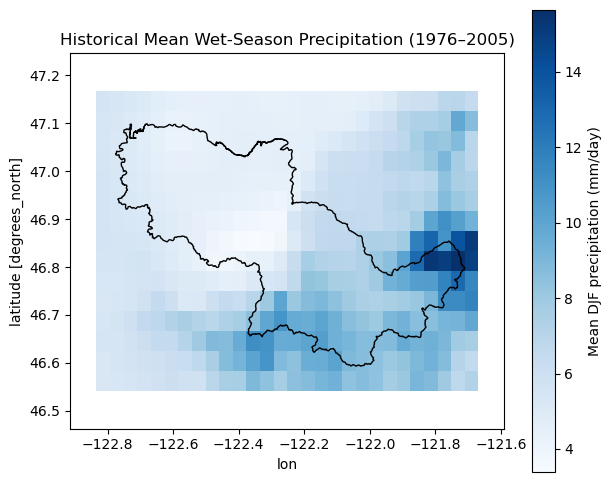

In [90]:
# Create figure and axis for plotting historical
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the historical wet-season mean precipitation raster
pr_hist_wet_mean.plot(
    ax=ax,
    cmap="Blues", # Blue color scale
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"} # Add label
)

# Convert watershed boundary to match raster CRS (EPSG:4326)
# and overlay it on the map for spatial reference
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add a visual buffer around the raster extent
buffer = 0.1

# Expand x-axis limits
ax.set_xlim(
    float(pr_hist_wet_mean.lon.min()) - buffer,
    float(pr_hist_wet_mean.lon.max()) + buffer
)

# Expand y-axis limits
ax.set_ylim(
    float(pr_hist_wet_mean.lat.min()) - buffer,
    float(pr_hist_wet_mean.lat.max()) + buffer
)

# Add a descriptive title for the map
ax.set_title("Historical Mean Wet-Season Precipitation (1976–2005)")

# Display the plot
plt.show()

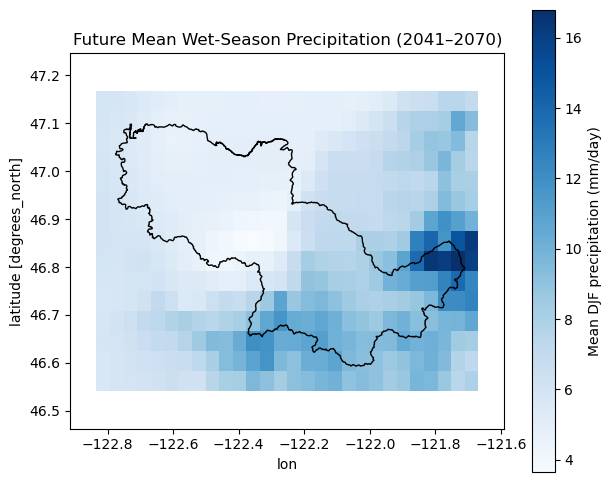

In [91]:
# Create figure and axis for plotting future
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the future wet-season mean precipitation raster
pr_future_wet_mean.plot(
    ax=ax,
    cmap="Blues",  # Blue color scale
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"}  # Add label
)

# Convert watershed boundary to match raster CRS (EPSG:4326)
# and overlay it on the map for spatial reference
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add a visual buffer around the raster extent
buffer = 0.1

# Expand x-axis limits (longitude)
ax.set_xlim(
    float(pr_future_wet_mean.lon.min()) - buffer,
    float(pr_future_wet_mean.lon.max()) + buffer
)

# Expand y-axis limits (latitude)
ax.set_ylim(
    float(pr_future_wet_mean.lat.min()) - buffer,
    float(pr_future_wet_mean.lat.max()) + buffer
)

# Add a descriptive title for the map
ax.set_title("Future Mean Wet-Season Precipitation (2041–2070)")

# Display the plot
plt.show()

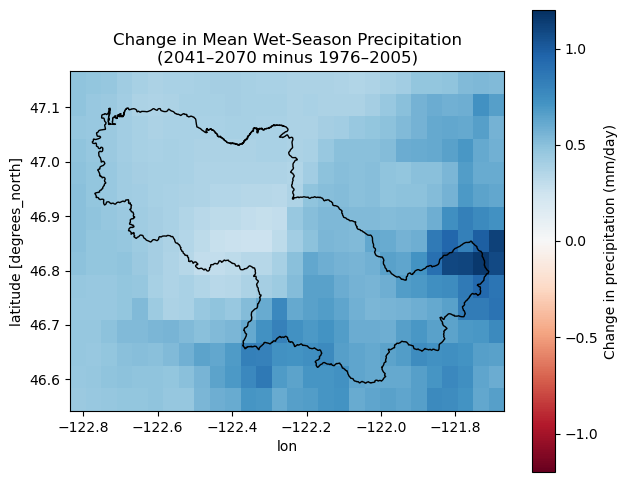

In [92]:
# Calculate the difference between future and historical wet-season precipitation
# Positive values indicate an increase in precipitation
delta_pr = pr_future_wet_mean - pr_hist_wet_mean

# Create figure and axis for plotting the difference map
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the difference raster
delta_pr.plot(
    ax=ax,
    cmap="RdBu", # Diverging colormap  (red = decrease, blue = increase)
    vmin=-1.2, # Set color scale evenly
    vmax=1.2,  # Set color scale evenly
    cbar_kwargs={"label": "Change in precipitation (mm/day)"}
)

# Add a descriptive title explaining the comparison
ax.set_title("Change in Mean Wet-Season Precipitation\n(2041–2070 minus 1976–2005)")

# Overlay watershed boundary for spatial reference
nisqually_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# Display the plot
plt.show()

In [93]:
# Double check min / max values
print(float(delta_pr.min()))
print(float(delta_pr.max()))

0.25664854049682617
1.153390884399414


##### Rx1day Climate Calculation - Storm Intensity Proxy

In [94]:
# Historical Rx1day calculations
# Subset to highest day in a year
annual_max_hist = pr_hist.resample(time="YE").max()

# Take the mean of all the years Rx1day
rx1day_hist_mean = annual_max_hist.mean(dim="time")

# Future Rx1day calculations
# Subset to highest day in a year
annual_max_fut = pr_fut.resample(time="YE").max()

# Take the mean of all the years Rx1day
rx1day_fut_mean = annual_max_fut.mean(dim="time")

In [95]:
# Check out the min/max to make sure the values make sense
print("Historical Rx1day min/max:")
print(float(rx1day_hist_mean.min()), float(rx1day_hist_mean.max()))

print("Future Rx1day min/max:")
print(float(rx1day_fut_mean.min()), float(rx1day_fut_mean.max()))

Historical Rx1day min/max:
35.734840393066406 135.65138244628906
Future Rx1day min/max:
33.55461120605469 141.6044158935547


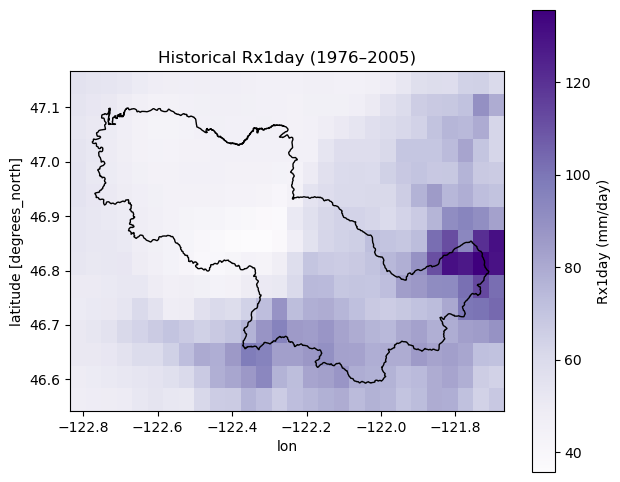

In [96]:
# Create figure and axis for plotting historical Rx1day
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the historical Rx1day raster
rx1day_hist_mean.plot(
    ax=ax,
    cmap="Purples",  # Good for extreme values
    cbar_kwargs={"label": "Rx1day (mm/day)"}  # Add label
)

# Overlay watershed boundary
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add title
ax.set_title("Historical Rx1day (1976–2005)")

# Display plot
plt.show()

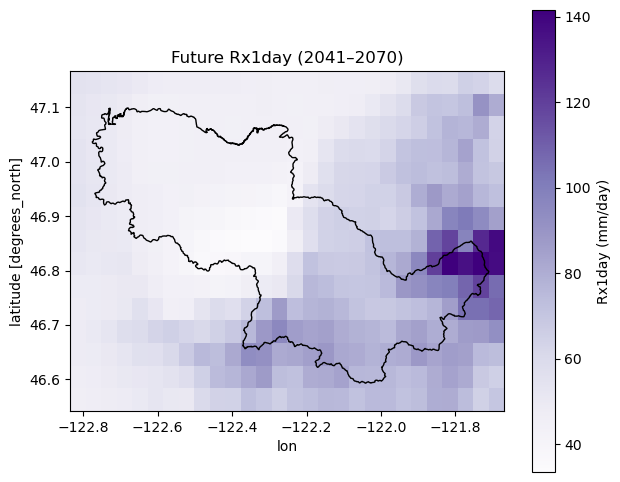

In [97]:
# Create figure and axis for plotting future Rx1day
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the future Rx1day raster
rx1day_fut_mean.plot(
    ax=ax,
    cmap="Purples",
    cbar_kwargs={"label": "Rx1day (mm/day)"}
)

# Overlay watershed boundary
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add title
ax.set_title("Future Rx1day (2041–2070)")

# Display plot
plt.show()

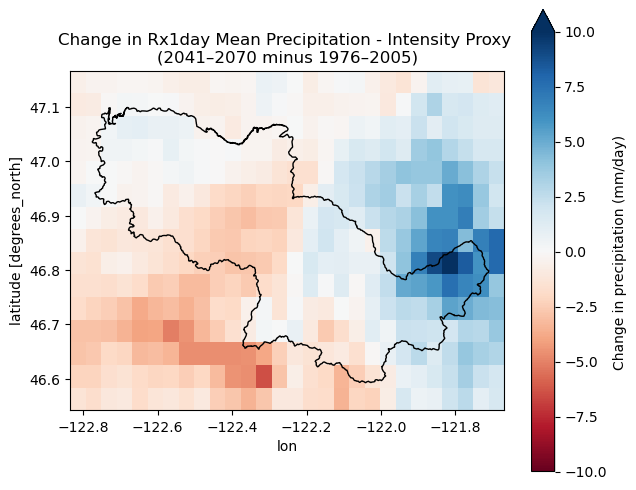

In [98]:
# Calculate the difference between future and historical wet-season precipitation
# Positive values indicate an increase in precipitation
change_pr_max = rx1day_fut_mean - rx1day_hist_mean

# Create figure and axis for plotting the difference map
fig, ax = plt.subplots(figsize=(7, 6))

# Plot the difference raster
change_pr_max.plot(
    ax=ax,
    cmap="RdBu", # Diverging colormap  (red = decrease, blue = increase)
    vmin=-10, # Set color scale evenly
    vmax=10,  # Set color scale evenly
    cbar_kwargs={"label": "Change in precipitation (mm/day)"}
)

# Add a descriptive title explaining the comparison
ax.set_title("Change in Rx1day Mean Precipitation - Intensity Proxy \n(2041–2070 minus 1976–2005)")

# Overlay watershed boundary for spatial reference
nisqually_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# Display the plot
plt.show()

In [99]:
# Create function to prepare raster for export
# *Created with help of ChatGPT, refined by author*
def prep_raster_for_export(da, x_dim="lon", y_dim="lat", crs="EPSG:4326"):
    """
    Set spatial dimensions and CRS on a DataArray before export.

    Args:
        da (xarray.DataArray): DataArray to prepare
        x_dim (str): Name of longitude dimension. Default is "lon".
        y_dim (str): Name of latitude dimension. Default is "lat".
        crs (str): Coordinate reference system to set. Default is "EPSG:4326".

    Returns:
        xarray.DataArray: Prepared DataArray with spatial metadata
    """
    # Set spatial dimensions and CRS using rioxarray
    da = da.rio.set_spatial_dims(x_dim=x_dim, y_dim=y_dim)
    da = da.rio.write_crs(crs)
    return da

In [100]:
# Calculate the paths for all climate rasters to be exported
# Calculate mean wet season precipitation
pr_hist_wet_mean = prep_raster_for_export(pr_hist_wet_mean)
pr_fut_wet_mean = prep_raster_for_export(pr_future_wet_mean)

# Calculate mean Rx1day
rx1day_hist_mean = prep_raster_for_export(rx1day_hist_mean)
rx1day_fut_mean = prep_raster_for_export(rx1day_fut_mean)

In [101]:
# Check that the spatial dimensions and CRS are set correctly
print(pr_hist_wet_mean.rio.crs)
print(pr_hist_wet_mean.rio.x_dim, pr_hist_wet_mean.rio.y_dim)

EPSG:4326
lon lat


In [102]:
# Create function to write raster
def write_raster(da, out_path):
    """
    Save a climate xarray DataArray as a GeoTIFF raster.

    Args:
        da (xarray.DataArray): Raster to export
        out_path (str): File path for output GeoTIFF

    Returns:
        None
    """

    # Save the calculated raster to a GeoTIFF file
    da.rio.to_raster(out_path)
    print(f"Saved: {out_path}")

In [103]:
# Save the rasters as GeoTIFFs for plotting
write_raster(pr_hist_wet_mean, os.path.join(climate_dir, "pr_hist_djf_mean_4326.tif"))
write_raster(pr_future_wet_mean, os.path.join(climate_dir, "pr_fut_djf_mean_4326.tif"))
write_raster(rx1day_hist_mean, os.path.join(climate_dir, "rx1day_hist_mean_4326.tif"))
write_raster(rx1day_fut_mean, os.path.join(climate_dir, "rx1day_fut_mean_4326.tif"))

Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\pr_hist_djf_mean_4326.tif
Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\pr_fut_djf_mean_4326.tif
Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\rx1day_hist_mean_4326.tif
Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\rx1day_fut_mean_4326.tif


### Harmonization for Fuzzy Logic Model

#### Define reference raster - DEM Raster | ESPG:5070

In [104]:
# Open one of the saved rasters to create reference raster for harmonization
reference_raster_dem = rxr.open_rasterio(
    os.path.join(topography_dir, "nisqually_dem_5070.tif")
).squeeze()

In [105]:
# Load and inspect all rasters, comparing to the reference DEM raster 
reference_raster_dem.name = "reference_dem"

In [106]:
# Check the shape, CRS, resolution, bounds, and name of the reference raster
print(reference_raster_dem.shape) # Shape (height, width)
print(reference_raster_dem.rio.crs) # CRS check
print(reference_raster_dem.rio.resolution()) # Resolution (pixel size in x and y)
print(reference_raster_dem.rio.bounds()) # Bounds (left, bottom, right, top)
print(reference_raster_dem.name) # Name of the DataArray

(1173, 1407)
EPSG:5070
(70.40380313242441, -70.40380313242436)
(-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
reference_dem


#### Load and Inspect original rasters

In [107]:
# Create function to load and inspect a raster comparison to reference raster
# *Created with help of ChatGPT, refined by author*
def load_and_inspect_raster(path, name=None, default_crs=None, reference=None):
    """
    Load a single-band raster and inspect metadata important for harmonization.

    Args:
        path (str): Full path to raster file.
        name (str, optional): Custom name to assign to the raster.
        default_crs (str, optional): CRS to assign only if missing.
        reference (xarray.DataArray, optional): Reference raster for comparison.

    Returns:
        xarray.DataArray
    """

    # Open raster with rioxarray and squeeze to 2D if it has a band dimension
    da = rxr.open_rasterio(path).squeeze()

    # Assign name if provided
    if name is not None:
        da.name = name

    # Check if CRS is missing and assign default if provided
    if da.rio.crs is None:
        if default_crs is None:
            print(f"WARNING: {name or path} has no CRS assigned.")
        else:
            da = da.rio.write_crs(default_crs)
            print(f"WARNING: {name or path} had no CRS. Assigned {default_crs}.")

    # Inspect raster metadata
    print("\n----- Raster Inspection -----")
    print(f"Name:       {da.name}") # Name of the DataArray
    print(f"Shape:      {da.shape}") # Shape (height, width)
    print(f"Dimensions: {da.dims}") # Check dimensions
    print(f"CRS:        {da.rio.crs}") # CRS check
    print(f"Resolution: {da.rio.resolution()}") # Resolution (pixel size in x and y)
    print(f"Bounds:     {da.rio.bounds()}") # Bounds (left, bottom, right, top)
    print(f"Dtype:      {da.dtype}") # Data type of the raster values
    print(f"NoData:     {da.rio.nodata}") # NoData value

    # Compare to reference raster
    if reference is not None:
        print("\n--- Compared to Reference ---")
        print(f"Reference:       {reference.name}") # Name of the reference raster
        print(f"Same CRS:        {da.rio.crs == reference.rio.crs}") # CRS match
        print(f"Same Shape:      {da.shape == reference.shape}") # Shape match
        print(f"Same Resolution: {da.rio.resolution() == reference.rio.resolution()}") # Resolution match
        print(f"Same Bounds:     {da.rio.bounds() == reference.rio.bounds()}") # Bounds/extent match

    # Return the loaded DataArray
    return da

In [108]:
# Create a dictionary of raster names and paths for loading and inspection
rasters = {
    "dem": os.path.join(topography_dir, "nisqually_dem_5070.tif"),
    "slope": os.path.join(topography_dir, "nisqually_slope_5070.tif"),
    "flow_acc": os.path.join(topography_dir, "nisqually_flow_acc_5070.tif"),
    "impervious": os.path.join(impervious_dir, "nisqually_impervious_5070.tif"),
    "soil_score": os.path.join(soils_dir, "nisqually_soil_score_5070.tif"),
    "pr_hist_djf_mean": os.path.join(climate_dir, "pr_hist_djf_mean_4326.tif"),
    "pr_fut_djf_mean": os.path.join(climate_dir, "pr_fut_djf_mean_4326.tif"),
    "rx1day_hist_mean": os.path.join(climate_dir, "rx1day_hist_mean_4326.tif"),
    "rx1day_fut_mean": os.path.join(climate_dir, "rx1day_fut_mean_4326.tif"),
}

# Create an empty dictionary to store the loaded rasters
loaded = {}

# Loop through the rasters, load and inspect each one, and store in the loaded dictionary
for name, path in rasters.items():
    if not os.path.exists(path):
        print(f"WARNING: File not found for {name}: {path}")
        continue

    # Use the load_and_inspect_raster to compare to the reference DEM raster
    loaded[name] = load_and_inspect_raster(
        path=path,
        name=name,
        reference=reference_raster_dem
    )


----- Raster Inspection -----
Name:       dem
Shape:      (1173, 1407)
Dimensions: ('y', 'x')
CRS:        EPSG:5070
Resolution: (70.40380313242441, -70.40380313242436)
Bounds:     (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Dtype:      float32
NoData:     -9999.0

--- Compared to Reference ---
Reference:       reference_dem
Same CRS:        True
Same Shape:      True
Same Resolution: True
Same Bounds:     True

----- Raster Inspection -----
Name:       slope
Shape:      (1173, 1407)
Dimensions: ('y', 'x')
CRS:        EPSG:5070
Resolution: (70.40380313242441, -70.40380313242436)
Bounds:     (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Dtype:      float32
NoData:     -9999.0

--- Compared to Reference ---
Reference:       reference_dem
Same CRS:        True
Same Shape:      True
Same Resolution: True
Same Bounds:     True

----- Raster Inspection -----
Name:       flow_acc
Shape:      (1173, 1407)
Dimensions: ('y',

#### Harmonize Rasters

In [109]:
# Create a function to harmonize climate rasters to match the reference DEM raster
def harmonize_to_reference(path, name, reference_dem, input_crs="EPSG:4326", resampling_method=Resampling.bilinear):
    """Function to load the climate rasters, check/assign CRS, and reproject
    to match the reference DEM raster.
    
    Args:
        path (str): Path to the input climate raster.
        name (str): Name to assign to the loaded DataArray.
        reference_dem (xarray.DataArray): Reference DEM raster to match.
        input_crs (str): CRS to assign if the input raster is missing CRS. Default is "EPSG:4326".
        
    Returns:
        xarray.DataArray: Harmonized climate raster matching the reference DEM."""
    
    da = rxr.open_rasterio(path).squeeze()
    da.name = name

    if da.rio.crs is None:
        da = da.rio.write_crs(input_crs)
        print(f"Assigned missing CRS {input_crs} to {name}")

    da_harmonized = da.rio.reproject_match(
        reference_dem,
    resampling=resampling_method    
    )

    da_harmonized.name = name

    if da_harmonized.ndim == 3:
        da_harmonized = da_harmonized.squeeze()

    return da_harmonized

In [110]:
# Define which rasters are continuous vs categorical for choosing resampling method
continuous_vars = [
    "slope",
    "flow_acc",
    "impervious",
    "pr_hist_djf_mean",
    "pr_fut_djf_mean",
    "rx1day_hist_mean",
    "rx1day_fut_mean"
]

# Categorigal variable
categorical_vars = [
    "soil_score"
]

# Create a new dictionary to store the harmonized rasters, starting with the DEM which is already the reference
harmonized_rasters = {
    "dem": loaded["dem"]
}

for name in continuous_vars + categorical_vars:
    print("Processing:", name)
    if name in continuous_vars:
        resampling_method = Resampling.bilinear
    else:
        resampling_method = Resampling.nearest

    harmonized_rasters[name] = harmonize_to_reference(
        path=rasters[name],
        name=name,
        reference_dem=reference_raster_dem,
        input_crs="EPSG:4326" if name in [
            "pr_hist_djf_mean",
            "pr_fut_djf_mean",
            "rx1day_hist_mean",
            "rx1day_fut_mean"
        ] else None,
        resampling_method=resampling_method
    )

Processing: slope
Processing: flow_acc
Processing: impervious
Processing: pr_hist_djf_mean
Processing: pr_fut_djf_mean
Assigned missing CRS EPSG:4326 to pr_fut_djf_mean
Processing: rx1day_hist_mean
Processing: rx1day_fut_mean
Processing: soil_score


#### Inspect Harmonized Rasters

In [111]:
# Loop through the harmonized rasters and inspect metadata, comparing to the reference DEM raster
for name, da in harmonized_rasters.items():

    print("\nRaster Inspection")
    print(f"Name:       {name}")
    print(f"Shape:      {da.shape}")
    print(f"CRS:        {da.rio.crs}")
    print(f"Resolution: {da.rio.resolution()}")
    print(f"Bounds:     {da.rio.bounds()}")

    print("\nCompared to Reference")
    print(f"Same CRS:        {da.rio.crs == reference_raster_dem.rio.crs}")
    print(f"Same Shape:      {da.shape == reference_raster_dem.shape}")
    print(f"Same Resolution: {da.rio.resolution() == reference_raster_dem.rio.resolution()}")
    print(f"Same Bounds:     {da.rio.bounds() == reference_raster_dem.rio.bounds()}")


Raster Inspection
Name:       dem
Shape:      (1173, 1407)
CRS:        EPSG:5070
Resolution: (70.40380313242441, -70.40380313242436)
Bounds:     (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

Compared to Reference
Same CRS:        True
Same Shape:      True
Same Resolution: True
Same Bounds:     True

Raster Inspection
Name:       slope
Shape:      (1173, 1407)
CRS:        EPSG:5070
Resolution: (70.40380313242441, -70.40380313242436)
Bounds:     (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

Compared to Reference
Same CRS:        True
Same Shape:      True
Same Resolution: True
Same Bounds:     True

Raster Inspection
Name:       flow_acc
Shape:      (1173, 1407)
CRS:        EPSG:5070
Resolution: (70.40380313242441, -70.40380313242436)
Bounds:     (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

Compared to Reference
Same CRS:        True
Same Shape:      True
Same Resolution: True
S

#### Save Harmonized Rasters

#### Save all model inputs in input folder

In [112]:
# Make inputs folder for final harmonized rasters
inputs_dir = os.path.join(project_dir, "final_inputs_5070")
os.makedirs(inputs_dir, exist_ok=True)

In [113]:
# Save all harmonized rasters to the final inputs folder
for name, da in harmonized_rasters.items():
    output_path = os.path.join(inputs_dir, f"{name}_5070.tif")
    da.rio.to_raster(output_path)
    print(f"Saved {name} to {output_path}")

Saved dem to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\dem_5070.tif
Saved slope to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\slope_5070.tif
Saved flow_acc to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\flow_acc_5070.tif
Saved impervious to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\impervious_5070.tif
Saved pr_hist_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\pr_hist_djf_mean_5070.tif
Saved pr_fut_djf_mean to C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\final_inputs_5070\pr_fut_djf_mean_5070.tif
Save

#### Final Check 

In [114]:
# Check that all model inputs share the same grid information
for name, da in harmonized_rasters.items():
    print(name, da.shape, da.rio.resolution(), da.rio.crs)

dem (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
slope (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
flow_acc (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
impervious (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
pr_hist_djf_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
pr_fut_djf_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
rx1day_hist_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
rx1day_fut_mean (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070
soil_score (1173, 1407) (70.40380313242441, -70.40380313242436) EPSG:5070


In [115]:
# Check that raster bounds match the reference DEM
for name, da in harmonized_rasters.items():
    print(name)
    print("Raster bounds:   ", da.rio.bounds())
    print("Reference bounds:", reference_raster_dem.rio.bounds())
    print()

dem
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

slope
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

flow_acc
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

impervious
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)

pr_hist_djf_mean
Raster bounds:    (-2034093.5847268822, 2885199.5497459723, -1935035.433719561, 2967783.210820306)
Reference bounds: (-2034093.5847268822, 2885199.5497459723

Final model inputs include:
- slope
- flow accumulation
- soil runoff score
- wet season mean precipitation (historical + future)
- extreme precipitation (Rx1day historical + future)

#### Look for breakpoints 

#### Impervious Surface

 Percent impervious surface was assigned an increasing sigmoid membership function using literature-informed anchors: 15% as the low runoff-response threshold, 40% as the midpoint transition value, and 75% as the high runoff-response threshold. Based on 

- 10–20% impervious → runoff starts increasing
- 35–50% impervious → moderate transition zone
- 75–100% impervious → high runoff response

Source:  US EPA https://www.epa.gov/caddis/urbanization-stormwater-runoff
& Paul MJ & Meyer JL. 2001. The ecology of urban streams. Annual Review of Ecology & Systematics 32:333-365.

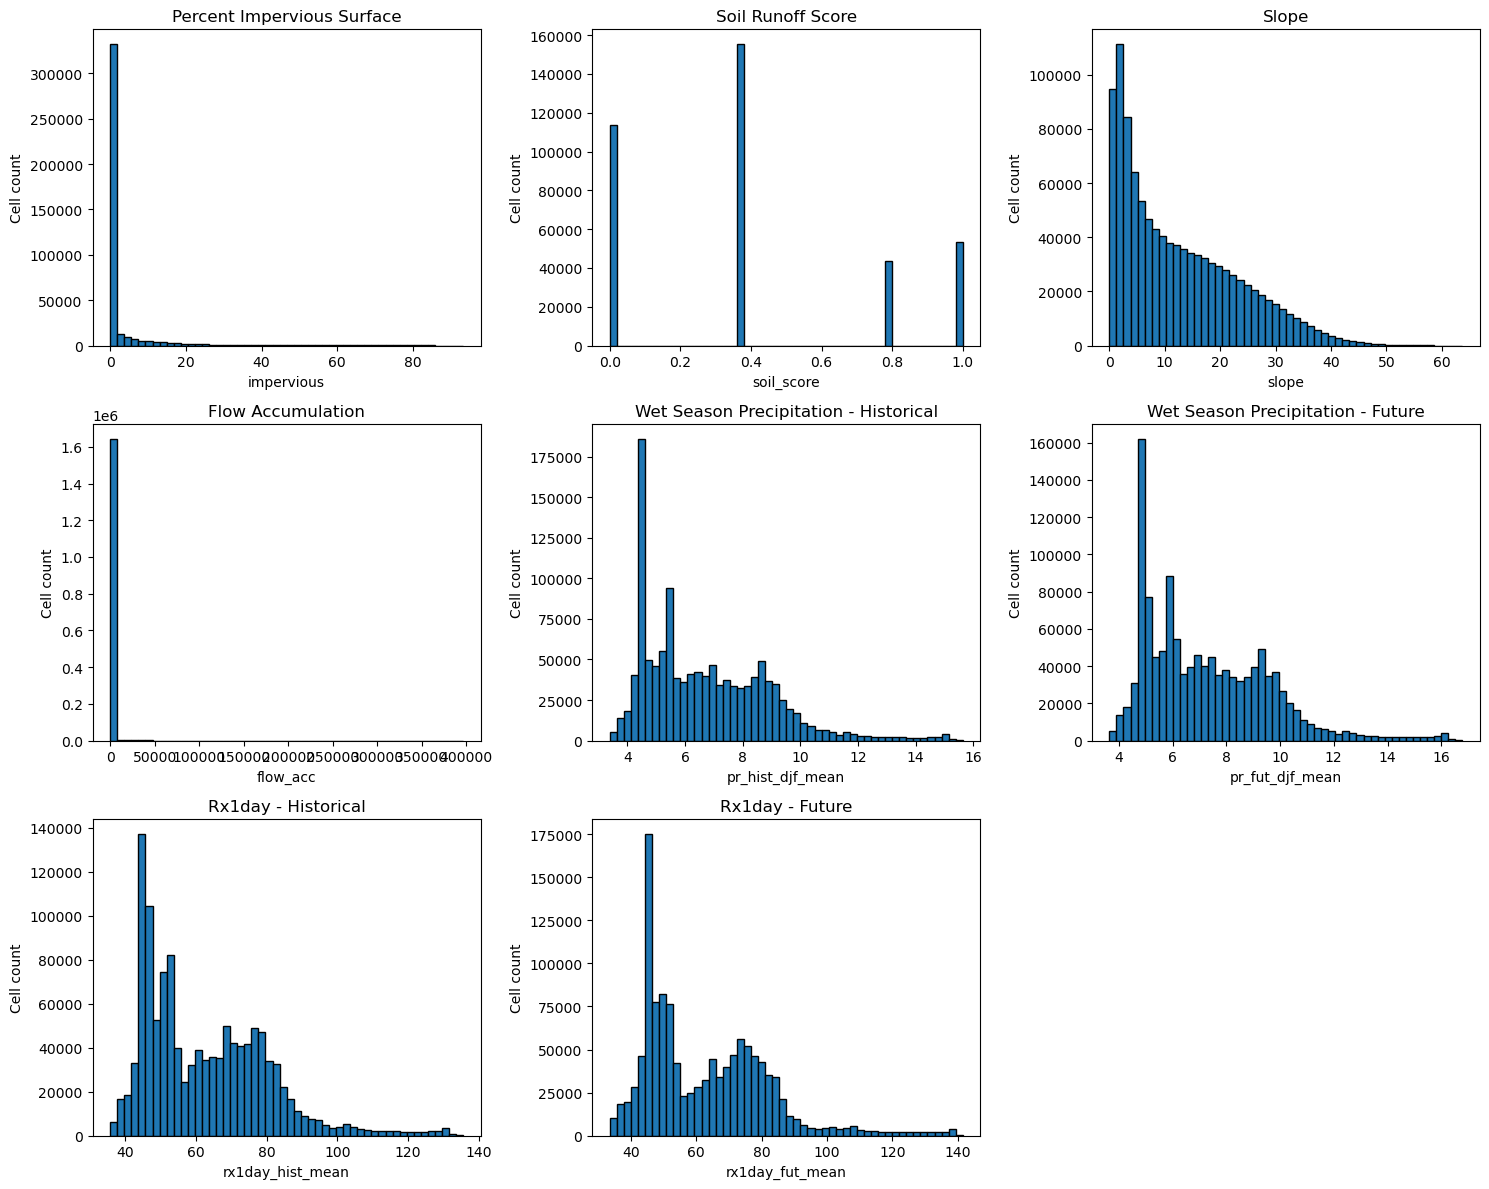

In [116]:
# Create variables list for histogram plotting
variables = [
    "impervious",
    "soil_score",
    "slope",
    "flow_acc",
    "pr_hist_djf_mean",
    "pr_fut_djf_mean",
    "rx1day_hist_mean",
    "rx1day_fut_mean"
]

# Create readable titles for histogram plots
titles = [
    "Percent Impervious Surface",
    "Soil Runoff Score",
    "Slope",
    "Flow Accumulation",
    "Wet Season Precipitation - Historical",
    "Wet Season Precipitation - Future",
    "Rx1day - Historical",
    "Rx1day - Future"
]

# Set axis 3 columns 3 rows for histograms
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# Loop through the harmonized rasters and plot histograms of the values for each variable, skipping the DEM
for ax, var, title in zip(axes, variables, titles):
    da = harmonized_rasters[var]
    data = da.values

    # Deal with NoData values by masking them out of the data array before plotting
    nodata = da.rio.nodata
    if nodata is not None and not np.isnan(nodata):
        data = data[data != nodata]

    # Mask out any NaN values
    data = data[~np.isnan(data)]

    # Plot histogram of the data values
    ax.hist(data, bins=50, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel(var)
    ax.set_ylabel("Cell count")

# Hide any unused subplots
for ax in axes[len(variables):]:
    ax.set_visible(False)

# Show the histograms
plt.tight_layout()
plt.show()

In [117]:
# Print summary statistics for each variable
for var in variables:
    
    # Get the data array and values for the variable
    da = harmonized_rasters[var]
    data = da.values

    # Deal with nodata by masking them
    nodata = da.rio.nodata

    if nodata is not None and not np.isnan(nodata):
        data = data[data != nodata]

    data = data[~np.isnan(data)]

    # Print the percentiles 
    print(f"\n{var}")
    print("Min:", np.min(data))
    print("P25:", np.percentile(data, 25))
    print("P50:", np.percentile(data, 50))
    print("P75:", np.percentile(data, 75))
    print("P90:", np.percentile(data, 90))
    print("P95:", np.percentile(data, 95))
    print("Max:", np.max(data))


impervious
Min: 0.0
P25: 0.0
P50: 0.0
P75: 0.0
P90: 8.031737
P95: 17.611252
Max: 93.27611

soil_score
Min: 0.0
P25: 0.0
P50: 0.37
P75: 0.78
P90: 1.0
P95: 1.0
Max: 1.0

slope
Min: 0.0
P25: 3.3822176
P50: 9.89358
P75: 19.710045
P90: 28.256035
P95: 32.960747
Max: 63.689293

flow_acc
Min: 1.0
P25: 1.0
P50: 2.0
P75: 10.0
P90: 136.0
P95: 395.0
Max: 396556.0

pr_hist_djf_mean
Min: 3.39079
P25: 4.8229656
P50: 6.276033
P75: 8.25646
P90: 9.457328
P95: 10.509016
Max: 15.632093

pr_fut_djf_mean
Min: 3.6475008
P25: 5.2240505
P50: 6.777829
P75: 8.889509
P90: 10.159313
P95: 11.288025
Max: 16.78484

rx1day_hist_mean
Min: 35.73995
P25: 47.466133
P50: 59.193436
P75: 74.7423
P90: 83.79143
P95: 92.57348
Max: 135.59563

rx1day_fut_mean
Min: 33.557934
P25: 46.759827
P50: 58.67975
P75: 75.207275
P90: 84.70138
P95: 95.24441
Max: 141.56252


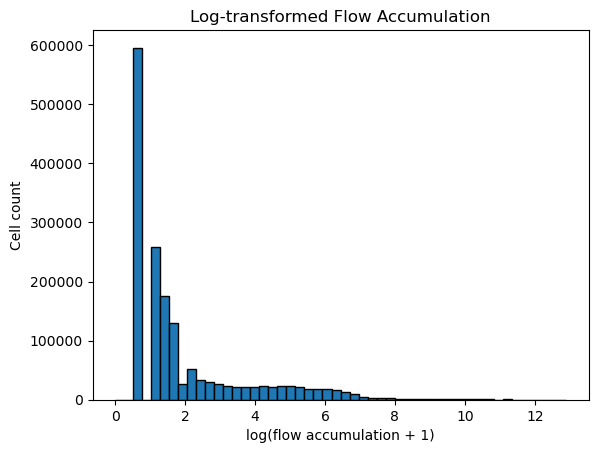

In [118]:
# Log transform flow accumulation for better visualization and reduce skew
flow = harmonized_rasters["flow_acc"].values
flow = flow[~np.isnan(flow)]

# Plot histogram of log-transformed flow accumulation
plt.hist(np.log1p(flow), bins=50, edgecolor="black")
plt.title("Log-transformed Flow Accumulation")
plt.xlabel("log(flow accumulation + 1)")
plt.ylabel("Cell count")
plt.show()

In [119]:
# Percentiles of log-transformed flow accumulation
flow = harmonized_rasters["flow_acc"].values

# Mask out NoData and NaN values
flow = flow[flow > 0]

# Log transform the flow accumulation values for better visualization and to reduce skew
log_flow = np.log1p(flow)

# Loop for percentiles and print
for p in [25, 50, 75, 90, 95]:
    print(p, np.percentile(log_flow, p))

25 0.6931471805599453
50 1.0986122886681098
75 2.3978952727983707
90 4.919980925828125
95 5.981414211254481


#### Thoughts on breakpoints from data visualization
| Variable              | Breakpoint approach                |
| --------------------- | ---------------------------------- |
| Impervious            | Literature (15, 40, 75)            |
| Soil score            | Category (0 - 1)                   |
| Slope                 | Physical thresholds or literature? |
| Flow accumulation     | Percentiles??? Higher?             |
| Historical DJF precip | Percentiles                        |
| Future DJF precip     | Percentiles                        |
| Historical Rx1day     | Percentiles                        |
| Future Rx1day         | Percentiles                        |


Flow acc - Chat GPT AI recommendation -> 10, 136, and 395

SLope - 5°, 15°, 30°

"From a slope perspective, the contribution to the total sediment yield was higher in the gentle slope class (5–15 degrees), followed by the moderately steep slope class (15–30 degrees). However, the steep slope class observed a higher mean sediment yield (30–45 degrees), with the highest mean soil erosion" https://link.springer.com/article/10.1007/s43621-025-01427-y

<5°      gentle
5–15°    moderate
15–30°   steep hillslope
>30°     very steep

https://www.mdpi.com/1999-4907/12/1/49

slope may not just purely increase runoff, may want to consider weighting slope less in runoff generation

#### Fuzzy Logic Model

##### Testing Membership function values, b = midpoint, c = steepness of curve

In [ ]:
# Run a test of the sigmoid membership function with some example values
test_values = np.array([0, 15, 40, 75, 100])

# Test the midpoint breakpoint to see if the membership function is working as expected
test_membership = fuzz.sigmf(
    test_values,
    b=30, # Midpoint breakpoint for the sigmoid function
    c=0.12 # Steepness of the curve (higher values = steeper curve)
)

# Calculate the membership values for the test values and print them rounded to 3 decimal places
for value, membership in zip(test_values, test_membership): 
    print(value, round(membership, 3))

0 0.002
15 0.023
40 0.5
75 0.995
100 1.0


In [ ]:
# Test different midpoints to see how the membership function changes
test_values = np.array([0, 10, 15, 25, 30, 40, 75, 100])

# Test different midpoints for the sigmoid membership function and print the results
for b in [25, 30, 40]:
    memberships = fuzz.sigmf(test_values, b=b, c=0.12)
    print(f"\nb = {b}")
    for value, membership in zip(test_values, memberships):
        print(value, round(membership, 3))


b = 25
0 0.047
10 0.142
15 0.231
25 0.5
30 0.646
40 0.858
75 0.998
100 1.0

b = 30
0 0.027
10 0.083
15 0.142
25 0.354
30 0.5
40 0.769
75 0.996
100 1.0

b = 40
0 0.008
10 0.027
15 0.047
25 0.142
30 0.231
40 0.5
75 0.985
100 0.999


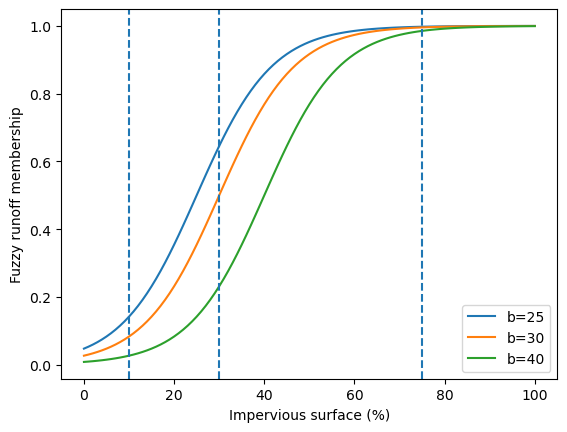

In [ ]:
# Plot the sigmoid membership function for different midpoints to visualize how it changes
x = np.arange(0, 101, 1)

# Plot the sigmoid membership function for different midpoints to visualize how it changes
plt.plot(x, fuzz.sigmf(x, b=25, c=0.12), label="b=25")
plt.plot(x, fuzz.sigmf(x, b=30, c=0.12), label="b=30")
plt.plot(x, fuzz.sigmf(x, b=40, c=0.12), label="b=40")

plt.axvline(10, linestyle="--")
plt.axvline(30, linestyle="--")
plt.axvline(75, linestyle="--")

plt.xlabel("Impervious surface (%)")
plt.ylabel("Fuzzy runoff membership")
plt.legend()
plt.show()

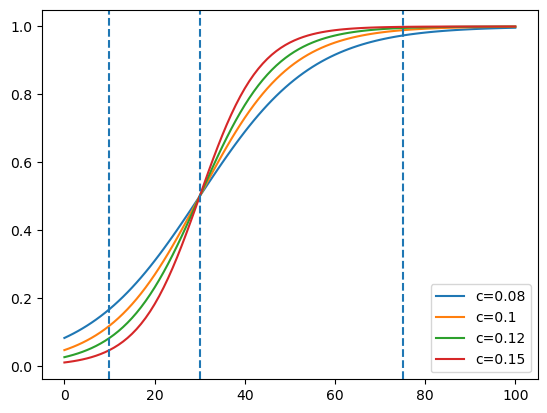

In [129]:
# Test different c values (steepness of the curve)
for c in [0.08, 0.10, 0.12, 0.15]:
    plt.plot(
        x,
        fuzz.sigmf(x, b=30, c=c), #midpoint constant, varying steepness
        label=f"c={c}"
    )

plt.axvline(10, linestyle="--")
plt.axvline(30, linestyle="--")
plt.axvline(75, linestyle="--")

plt.legend()
plt.show()

##### Test workflow on one layer

In [ ]:
# Test one layer 
test_impervious = harmonized_rasters["impervious"]

# Run increasing sigmoid membership function on the impervious raster
test_impervious_fuzzy = xr.DataArray(
    fuzz.sigmf(
        test_impervious.values,
        b=30, # Select midpoint / breakpoint for the sigmoid function
        c=0.12 # Select steepness of the curve (higher values = steeper curve)
    ),
    coords=test_impervious.coords, # Retain the original coordinates of the raster
    dims=test_impervious.dims, # Retain the original dimensions of the raster
    name="impervious_fuzzy" # Name the new DataArray for clarity
)

c:\Users\nymve\miniconda3\envs\earth-analytics-python\Lib\site-packages\skfuzzy\membership\generatemf.py:425: RuntimeWarning: overflow encountered in exp
  return 1. / (1. + np.exp(- c * (x - b)))


In [131]:
# Check original impervious raster range
print("Original impervious")
print("min:", float(test_impervious.min()))
print("max:", float(test_impervious.max()))
print("mean:", float(test_impervious.mean()))

# Check fuzzy raster range
print("\nFuzzy impervious")
print("min:", float(test_impervious_fuzzy.min()))
print("max:", float(test_impervious_fuzzy.max()))
print("mean:", float(test_impervious_fuzzy.mean()))

Original impervious
min: -9999.0
max: 93.27610778808594
mean: -7560.62841796875

Fuzzy impervious
min: 0.0
max: 0.9996618032455444
mean: 0.005136894527822733


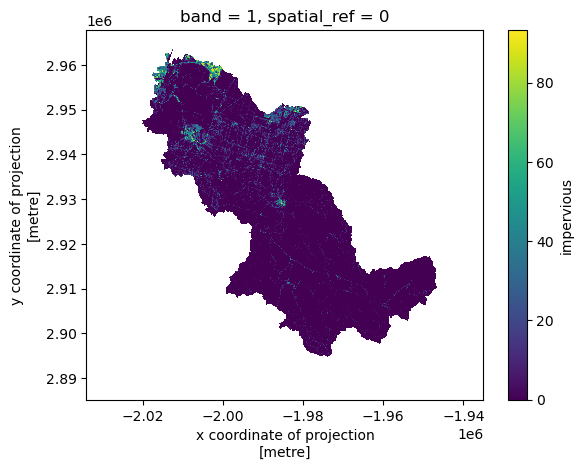

In [133]:
# Pull original raster
test_impervious = harmonized_rasters["impervious"]

# Mask NoData
test_impervious_masked = test_impervious.where(test_impervious != -9999)

# Plot masked original
test_impervious_masked.plot()

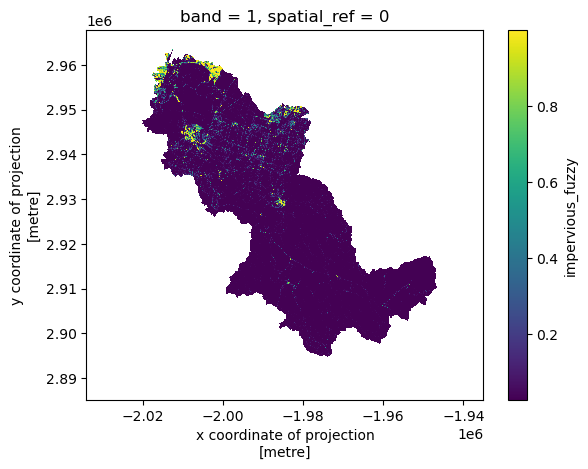

In [ ]:
# Rerun the fuzzy membership function on the masked nodata impervious raster
test_impervious_fuzzy = xr.DataArray(
    fuzz.sigmf(
        test_impervious_masked.values,
        b=30,
        c=0.12
    ),
    coords=test_impervious_masked.coords,
    dims=test_impervious_masked.dims,
    name="impervious_fuzzy"
)

# Plot the fuzzy impervious raster
test_impervious_fuzzy.plot()

In [ ]:
# Check it again to see if the min/max/mean values make sense
print("Masked impervious")
print(float(test_impervious_masked.min()))
print(float(test_impervious_masked.max()))
print(float(test_impervious_masked.mean()))

# Check the fuzzy impervious raster again to see if the min/max/mean values make sense
print("\nFuzzy impervious")
print(float(test_impervious_fuzzy.min()))
print(float(test_impervious_fuzzy.max()))
print(float(test_impervious_fuzzy.mean()))

1248051
Masked impervious
0.0
93.27610778808594
2.776672840118408

Fuzzy impervious
0.026596995070576668
0.999496340751648
0.05865544080734253


In [141]:
# Check the NoData value types in the harmonized rasters
for name, da in harmonized_rasters.items():
    print(
        f"{name}:",
        "nodata =", da.rio.nodata,
        "\nNaNs =", int(np.isnan(da.values).sum())
    )

dem: nodata = -9999.0 
NaNs = 0
slope: nodata = -9999.0 
NaNs = 0
flow_acc: nodata = 0.0 
NaNs = 0
impervious: nodata = -9999.0 
NaNs = 0
pr_hist_djf_mean: nodata = nan 
NaNs = 423444
pr_fut_djf_mean: nodata = nan 
NaNs = 423444
rx1day_hist_mean: nodata = nan 
NaNs = 423444
rx1day_fut_mean: nodata = nan 
NaNs = 423444
soil_score: nodata = nan 
NaNs = 1284543


In [ ]:
def mask_raster_nodata(raster):
    """
    Mask NoData values in a raster while preserving valid zero values.

    Args:
        raster (xarray.DataArray): Input raster with NoData values.

    Returns:
        xarray.DataArray: Raster with NoData values masked as NaN.
    """

    # Get the NoData value from the raster metadata
    nodata = raster.rio.nodata

    # If nodata is NaN, mask out NaN values    
    if np.isnan(nodata):
        raster_masked = raster.where(~np.isnan(raster))

    # If nodata is -9999, mask out -9999 values
    elif nodata == -9999:
        raster_masked = raster.where(raster != -9999)

    # Leave the raster unchanged to avoid masking valid zero values.    
    else:
        raster_masked = raster

    return raster_masked

In [142]:
def fuzzy_sigmoid_increasing(raster, breakpoint, steepness, output_name):
    """
    Convert a raster to fuzzy membership using an increasing sigmoid function.

    Higher input values result in higher fuzzy membership values.

    Args:
        raster (xarray.DataArray): Input raster
        breakpoint (float): Sigmoid midpoint where membership equals 0.5
        steepness (float): Controls how quickly membership increases
        output_name (str): Name for the output fuzzy raster

    Returns:
        xarray.DataArray: Fuzzy raster with membership values from 0 to 1
    """

    # Mask NoData values before fuzzifying
    raster_masked = mask_raster_nodata(raster)

    # Apply increasing sigmoid membership function
    fuzzy_values = fuzz.sigmf(
        raster_masked.values,
        b=breakpoint,
        c=steepness
    )

    # Convert NumPy array back to xarray DataArray
    fuzzy_raster = xr.DataArray(
        fuzzy_values,
        coords=raster_masked.coords,
        dims=raster_masked.dims,
        name=output_name
    )

    # Verify fuzzy membership values are between 0 and 1
    assert float(fuzzy_raster.min()) >= 0, "Membership values are below 0."
    assert float(fuzzy_raster.max()) <= 1, "Membership values are above 1."

    return fuzzy_raster

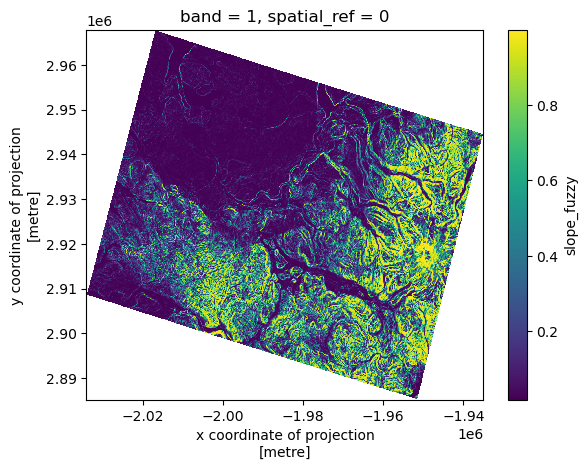

In [147]:
slope_fuzzy = fuzzy_sigmoid_increasing(
    raster=harmonized_rasters["slope"],
    breakpoint=20,
    steepness=0.2,
    output_name="slope_fuzzy"
)

slope_fuzzy.plot()